# Understanding the Run Sequence Plot

A run sequence plot plots the measured values **in the order they were collected** — run 1, run 2, run 3, … The x-axis is run index (or time); the y-axis is the response value. It is the first of the 4-Plot checks and answers: *Is the process location fixed? Is the variation fixed?*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

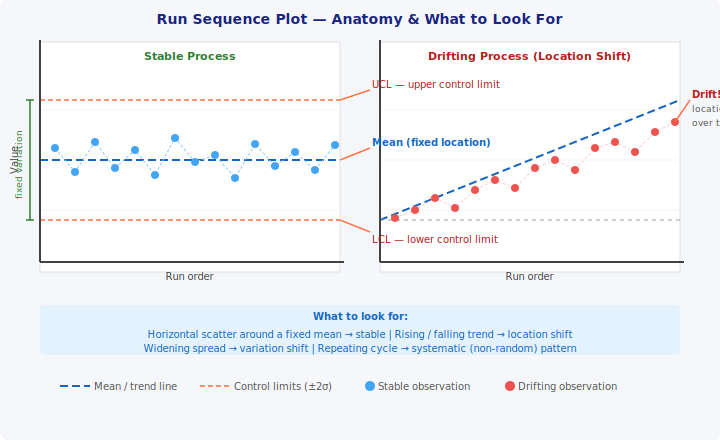

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="440"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="720" height="440" fill="#F5F7FA" rx="8"/>
  <text x="360" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Run Sequence Plot — Anatomy &amp; What to Look For</text>

  <!-- ── LEFT PANEL: Stable (fixed location + fixed variation) ── -->
  <rect x="40" y="42" width="300" height="230" fill="white" stroke="#E0E0E0"/>
  <text x="190" y="60" text-anchor="middle" font-size="11" font-weight="bold" fill="#2E7D32">Stable Process</text>

  <!-- gridlines -->
  <line x1="40" y1="110" x2="340" y2="110" stroke="#F5F5F5" stroke-width="1"/>
  <line x1="40" y1="160" x2="340" y2="160" stroke="#F5F5F5" stroke-width="1"/>
  <line x1="40" y1="210" x2="340" y2="210" stroke="#F5F5F5" stroke-width="1"/>

  <!-- Mean line -->
  <line x1="40" y1="160" x2="340" y2="160" stroke="#1565C0" stroke-width="2" stroke-dasharray="8,4"/>

  <!-- Upper control limit -->
  <line x1="40" y1="100" x2="340" y2="100" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="5,3"/>
  <!-- Lower control limit -->
  <line x1="40" y1="220" x2="340" y2="220" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="5,3"/>

  <!-- Data points scattered around mean -->
  <polyline points="55,148 75,172 95,142 115,168 135,150 155,175 175,138 195,162
                    215,155 235,178 255,144 275,166 295,152 315,170 335,145"
            fill="none" stroke="#90CAF9" stroke-width="1" stroke-dasharray="3,2"/>
  <circle cx="55"  cy="148" r="4" fill="#42A5F5"/>
  <circle cx="75"  cy="172" r="4" fill="#42A5F5"/>
  <circle cx="95"  cy="142" r="4" fill="#42A5F5"/>
  <circle cx="115" cy="168" r="4" fill="#42A5F5"/>
  <circle cx="135" cy="150" r="4" fill="#42A5F5"/>
  <circle cx="155" cy="175" r="4" fill="#42A5F5"/>
  <circle cx="175" cy="138" r="4" fill="#42A5F5"/>
  <circle cx="195" cy="162" r="4" fill="#42A5F5"/>
  <circle cx="215" cy="155" r="4" fill="#42A5F5"/>
  <circle cx="235" cy="178" r="4" fill="#42A5F5"/>
  <circle cx="255" cy="144" r="4" fill="#42A5F5"/>
  <circle cx="275" cy="166" r="4" fill="#42A5F5"/>
  <circle cx="295" cy="152" r="4" fill="#42A5F5"/>
  <circle cx="315" cy="170" r="4" fill="#42A5F5"/>
  <circle cx="335" cy="145" r="4" fill="#42A5F5"/>

  <!-- axes -->
  <line x1="40" y1="262" x2="344" y2="262" stroke="#424242" stroke-width="2"/>
  <line x1="40" y1="262" x2="40"  y2="40"  stroke="#424242" stroke-width="2"/>
  <text x="190" y="280" text-anchor="middle" font-size="10" fill="#424242">Run order</text>
  <text x="18" y="160" text-anchor="middle" font-size="10" fill="#424242"
        transform="rotate(-90 18 160)">Value</text>

  <!-- ── RIGHT PANEL: Drifting (non-fixed location) ── -->
  <rect x="380" y="42" width="300" height="230" fill="white" stroke="#E0E0E0"/>
  <text x="530" y="60" text-anchor="middle" font-size="11" font-weight="bold" fill="#B71C1C">Drifting Process (Location Shift)</text>

  <!-- gridlines -->
  <line x1="380" y1="110" x2="680" y2="110" stroke="#F5F5F5" stroke-width="1"/>
  <line x1="380" y1="160" x2="680" y2="160" stroke="#F5F5F5" stroke-width="1"/>
  <line x1="380" y1="210" x2="680" y2="210" stroke="#F5F5F5" stroke-width="1"/>

  <!-- Drifting mean line -->
  <line x1="380" y1="220" x2="680" y2="100" stroke="#1565C0" stroke-width="2" stroke-dasharray="8,4"/>
  <!-- Old mean reference -->
  <line x1="380" y1="220" x2="680" y2="220" stroke="#90A4AE" stroke-width="1" stroke-dasharray="4,4"/>

  <!-- Data points drifting upward -->
  <polyline points="395,218 415,210 435,198 455,208 475,190 495,180 515,188
                    535,168 555,160 575,170 595,148 615,142 635,152 655,132 675,122"
            fill="none" stroke="#FFCDD2" stroke-width="1" stroke-dasharray="3,2"/>
  <circle cx="395" cy="218" r="4" fill="#EF5350"/>
  <circle cx="415" cy="210" r="4" fill="#EF5350"/>
  <circle cx="435" cy="198" r="4" fill="#EF5350"/>
  <circle cx="455" cy="208" r="4" fill="#EF5350"/>
  <circle cx="475" cy="190" r="4" fill="#EF5350"/>
  <circle cx="495" cy="180" r="4" fill="#EF5350"/>
  <circle cx="515" cy="188" r="4" fill="#EF5350"/>
  <circle cx="535" cy="168" r="4" fill="#EF5350"/>
  <circle cx="555" cy="160" r="4" fill="#EF5350"/>
  <circle cx="575" cy="170" r="4" fill="#EF5350"/>
  <circle cx="595" cy="148" r="4" fill="#EF5350"/>
  <circle cx="615" cy="142" r="4" fill="#EF5350"/>
  <circle cx="635" cy="152" r="4" fill="#EF5350"/>
  <circle cx="655" cy="132" r="4" fill="#EF5350"/>
  <circle cx="675" cy="122" r="4" fill="#EF5350"/>

  <!-- axes -->
  <line x1="380" y1="262" x2="684" y2="262" stroke="#424242" stroke-width="2"/>
  <line x1="380" y1="262" x2="380" y2="40"  stroke="#424242" stroke-width="2"/>
  <text x="530" y="280" text-anchor="middle" font-size="10" fill="#424242">Run order</text>

  <!-- ── ANNOTATIONS (left panel) ── -->
  <!-- Mean line label -->
  <line x1="340" y1="160" x2="370" y2="148" stroke="#FF7043" stroke-width="1.5"/>
  <text x="372" y="146" font-size="10" font-weight="bold" fill="#1565C0">Mean (fixed location)</text>

  <!-- UCL label -->
  <line x1="340" y1="100" x2="370" y2="90" stroke="#FF7043" stroke-width="1.5"/>
  <text x="372" y="88" font-size="10" fill="#B71C1C">UCL — upper control limit</text>

  <!-- LCL label -->
  <line x1="340" y1="220" x2="370" y2="232" stroke="#FF7043" stroke-width="1.5"/>
  <text x="372" y="243" font-size="10" fill="#B71C1C">LCL — lower control limit</text>

  <!-- Variation bracket -->
  <line x1="30" y1="100" x2="30" y2="220" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="26" y1="100" x2="34" y2="100" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="26" y1="220" x2="34" y2="220" stroke="#2E7D32" stroke-width="1.5"/>
  <text x="22" y="165" text-anchor="middle" font-size="9" fill="#2E7D32"
        transform="rotate(-90 22 165)">fixed variation</text>

  <!-- Right panel: drift annotation -->
  <line x1="675" y1="122" x2="690" y2="100" stroke="#FF7043" stroke-width="1.5"/>
  <text x="692" y="98" font-size="10" font-weight="bold" fill="#B71C1C">Drift!</text>
  <text x="692" y="112" font-size="9" fill="#555">location shifts</text>
  <text x="692" y="126" font-size="9" fill="#555">over time</text>

  <!-- ── BOTTOM TAKEAWAY ── -->
  <rect x="40" y="305" width="640" height="50" fill="#E3F2FD" rx="4"/>
  <text x="360" y="320" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="360" y="338" text-anchor="middle" font-size="10" fill="#1565C0">Horizontal scatter around a fixed mean → stable   |   Rising / falling trend → location shift</text>
  <text x="360" y="352" text-anchor="middle" font-size="10" fill="#1565C0">Widening spread → variation shift   |   Repeating cycle → systematic (non-random) pattern</text>

  <!-- Legend -->
  <line x1="60" y1="386" x2="90" y2="386" stroke="#1565C0" stroke-width="2" stroke-dasharray="8,4"/>
  <text x="94" y="390" font-size="10" fill="#555">Mean / trend line</text>
  <line x1="200" y1="386" x2="230" y2="386" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="5,3"/>
  <text x="234" y="390" font-size="10" fill="#555">Control limits (±2σ)</text>
  <circle cx="370" cy="386" r="5" fill="#42A5F5"/>
  <text x="378" y="390" font-size="10" fill="#555">Stable observation</text>
  <circle cx="510" cy="386" r="5" fill="#EF5350"/>
  <text x="518" y="390" font-size="10" fill="#555">Drifting observation</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Run Sequence Plot

| Pattern | What it means |
|---|---|
| **Horizontal band, random scatter** | Fixed location + fixed variation — assumptions satisfied |
| **Rising or falling trend** | Location shift — mean is changing over time |
| **Widening or narrowing spread** | Variation shift — standard deviation is changing |
| **Repeating up-down cycle** | Periodic / seasonal non-randomness |
| **Sudden jump** | Level shift — one-time structural change |
| **Outlier point** | Isolated anomaly — investigate cause |

**Connection to EDA Assumptions:** A good run sequence plot shows points randomly scattered in a horizontal band. Any deviation signals that one or more of the four EDA assumptions — fixed location, fixed variation, randomness, fixed distribution — is violated.

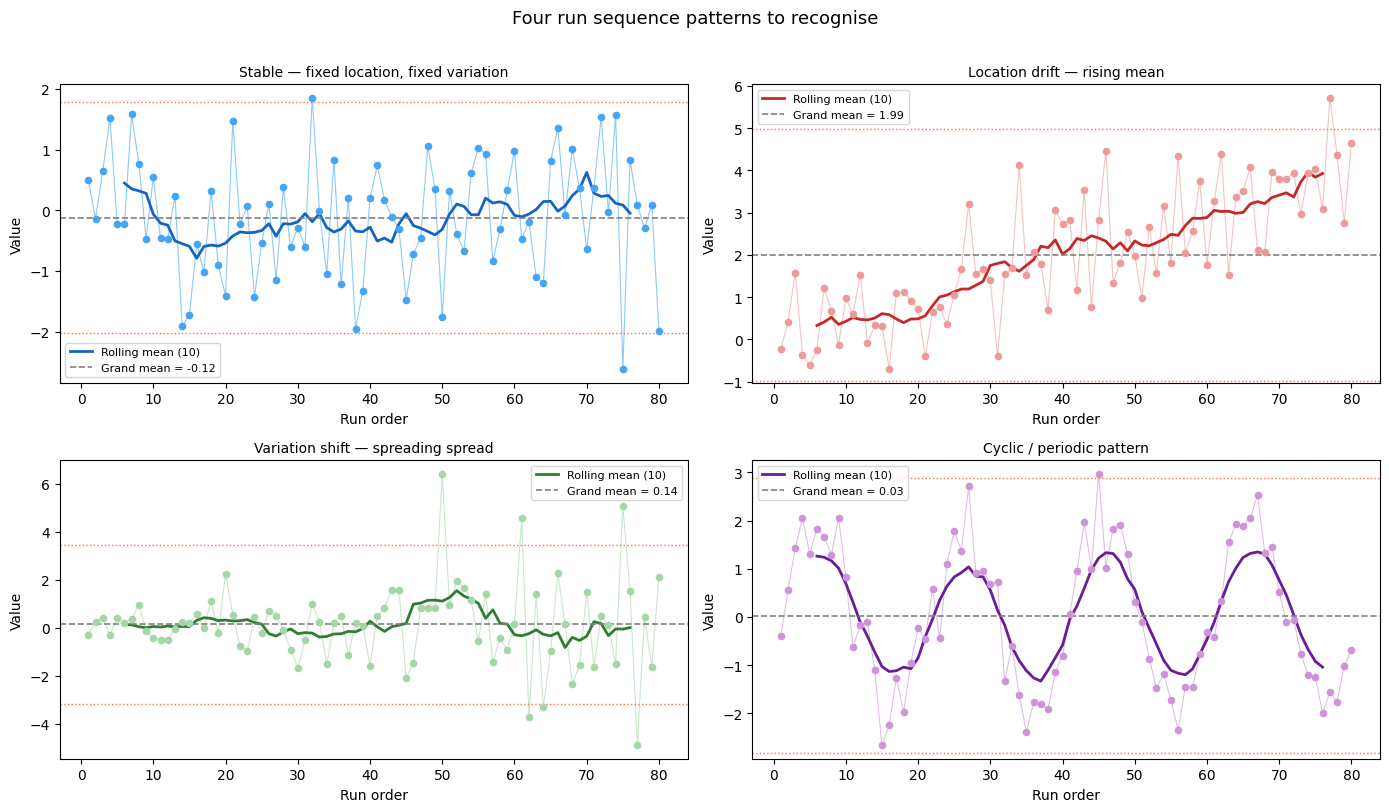

In [3]:
np.random.seed(42)
n = 80

# Four patterns
stable   = np.random.normal(0, 1, n)
drifting = np.linspace(0, 4, n) + np.random.normal(0, 1, n)
widening = np.random.normal(0, np.linspace(0.3, 2.5, n))
cyclic   = 2 * np.sin(2 * np.pi * np.arange(n) / 20) + np.random.normal(0, 0.5, n)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
datasets = [
    (stable,   'Stable — fixed location, fixed variation', '#42A5F5', '#1565C0'),
    (drifting, 'Location drift — rising mean', '#EF9A9A', '#C62828'),
    (widening, 'Variation shift — spreading spread', '#A5D6A7', '#2E7D32'),
    (cyclic,   'Cyclic / periodic pattern', '#CE93D8', '#6A1B9A'),
]

for ax, (data, title, pt_color, line_color) in zip(axes.flat, datasets):
    x = np.arange(1, n + 1)
    ax.plot(x, data, color=pt_color, linewidth=0.8, alpha=0.6)
    ax.scatter(x, data, color=pt_color, s=20, zorder=3)
    # running mean
    rm = pd.Series(data).rolling(10, center=True).mean()
    ax.plot(x, rm, color=line_color, linewidth=2, label='Rolling mean (10)')
    # grand mean
    ax.axhline(data.mean(), color='grey', linewidth=1.2, linestyle='--', label=f'Grand mean = {data.mean():.2f}')
    # ±2σ bands
    ax.axhline(data.mean() + 2*data.std(), color='#FF7043', linewidth=1, linestyle=':')
    ax.axhline(data.mean() - 2*data.std(), color='#FF7043', linewidth=1, linestyle=':')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Run order')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)

plt.suptitle('Four run sequence patterns to recognise', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Verifying EDA assumptions before modeling — fixed location, fixed variation |
| **X-axis** | Run index or time — order matters |
| **Y-axis** | Measured / response value |
| **Stable** | Points scatter randomly in a horizontal band |
| **Rolling mean** | Reveals slow trends invisible to the eye |
| **Control limits** | ±2σ band — points outside are anomalies |
| **Pairs with** | Lag plot (randomness) + Histogram + Q-Q plot = 4-Plot |